In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [29]:
load_dotenv()

False

In [ ]:
# import os
# from langchain_groq import ChatGroq

# os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")

# model = ChatGroq(
#     model="llama-3.3-70b-versatile",
#     temperature=0
# )

In [31]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixs: int

    sr: float
    boundary_percentage: float
    bpb: float
    summary: str

In [32]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    
    
    return {'sr': sr}

In [33]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours'] + state['sixs']
    bpb = (state['balls']/ total_boundaries) if total_boundaries > 0 else 0
    

    return {'bpb': bpb}

In [34]:
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    total_boundaries_runs = state['fours']*4 + state['sixs']*6
    boundary_percentage = (total_boundaries_runs / state['runs']) * 100
    return {'boundary_percentage': boundary_percentage}
     
   
   

In [47]:
def summary(state: BatsmanState) -> dict:
    summary = f"""
Strike Rate - {state['sr']:.2f} 
Boundary Percentage - {state['boundary_percentage']:.2f}
Balls per Boundary - {state['bpb']:.2f}
"""

    return {'summary': summary}

In [48]:
graph = StateGraph(BatsmanState)

#defining nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('summary', summary)

#defining edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge(START, 'calculate_bpb')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')
graph.add_edge('calculate_bpb', 'summary')

graph.add_edge('summary', END)

#compile the graph
workflow = graph.compile()

In [49]:
initial_state: BatsmanState = {
    'runs': 120,
    'balls': 80,
    'fours': 10,
    'sixs': 5}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 120, 'balls': 80, 'fours': 10, 'sixs': 5, 'sr': 150.0, 'boundary_percentage': 58.333333333333336, 'bpb': 5.333333333333333, 'summary': '\nStrike Rate - 150.00 \nBoundary Percentage - 58.33\nBalls per Boundary - 5.33\n'}


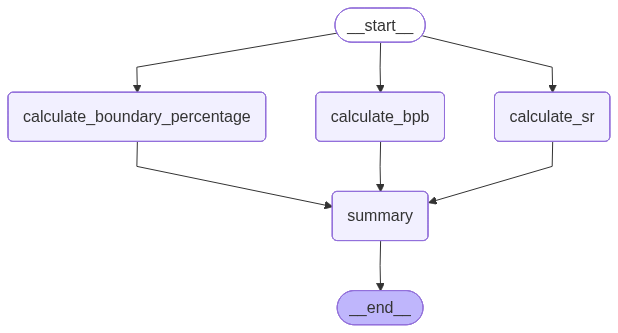

In [50]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())